# Complete Machine Learning Course - Loan Approval Prediction

### Import Libraries

In [22]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder  
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import export_text

print("✅ Libraries loaded successfully")
ARTIFACT_FOLDER = "loan_manager_app/artifacts"


✅ Libraries loaded successfully


### 1- Problem Definition

### 2- Data Collection

In [23]:
print("\n" + "=" * 70)
print("Step 1: Load Data from Database")
print("=" * 70)

conn = sqlite3.connect("loan_manager_app/bank.db")

query = """
SELECT 
    c.age,
    c.marital_status,
    c.dependents,
    e.employment_type,
    e.employment_years,
    e.monthly_income,
    cp.credit_score,
    l.loan_amount,
    l.loan_term_months,
    l.loan_purpose,
    l.has_other_loans,
    l.late_payments_last_year,
    l.approved
FROM customers c
JOIN employments e ON c.customer_id = e.customer_id
JOIN credit_profiles cp ON c.customer_id = cp.customer_id
JOIN loan_requests l ON c.customer_id = l.customer_id
WHERE l.approved IS NOT NULL
"""

df = pd.read_sql(query, conn)
conn.close()

print(f"Total records: {len(df):,}")
print(f"Total features: {len(df.columns)}")
print("\n📊 Target Distribution (approved):")
print(df["approved"].value_counts())
print(f"Approval rate: {df['approved'].mean() * 100:.1f}%")


Step 1: Load Data from Database
Total records: 5,000
Total features: 13

📊 Target Distribution (approved):
approved
1    3023
0    1977
Name: count, dtype: int64
Approval rate: 60.5%


### 3- Data Processing

#### Data Exploration (EDA)

In [24]:
print("\n" + "=" * 70)
print("Step 2: Exploratory Data Analysis (EDA)")
print("=" * 70)

# 2.1 Descriptive Statistics
print("\n📈 Descriptive Statistics of Numerical Features:")
print(df.describe())

# 2.2 Missing Values
print("\n🔍 Missing Values:")
print(df.isnull().sum())

# 2.3 Target Distribution
print("\n🎯 Target Distribution (approved):")
target_dist = df["approved"].value_counts(normalize=True)
print(f"   Rejected (0): {target_dist.get(0, 0) * 100:.1f}%")
print(f"   Approved (1): {target_dist.get(1, 0) * 100:.1f}%")


Step 2: Exploratory Data Analysis (EDA)

📈 Descriptive Statistics of Numerical Features:
               age   dependents  employment_years  monthly_income  \
count  5000.000000  5000.000000       5000.000000    5.000000e+03   
mean     43.559600     1.259000         14.151800    2.267798e+07   
std      12.809077     1.479174         12.611779    8.004864e+06   
min      22.000000     0.000000          0.000000    2.761542e+06   
25%      32.000000     0.000000          1.000000    1.817642e+07   
50%      43.000000     1.000000         12.000000    2.287948e+07   
75%      55.000000     2.000000         25.000000    2.772177e+07   
max      65.000000     4.000000         45.000000    4.553975e+07   

       credit_score   loan_amount  loan_term_months  has_other_loans  \
count   4884.000000  5.000000e+03        5000.00000      5000.000000   
mean     707.760647  1.130676e+08          42.15120         0.069200   
std      132.604369  5.792094e+07          20.40995         0.253819   


##### Data Visualization


Step 3: Data Visualizations
✅ EDA plots saved: eda_plots.png


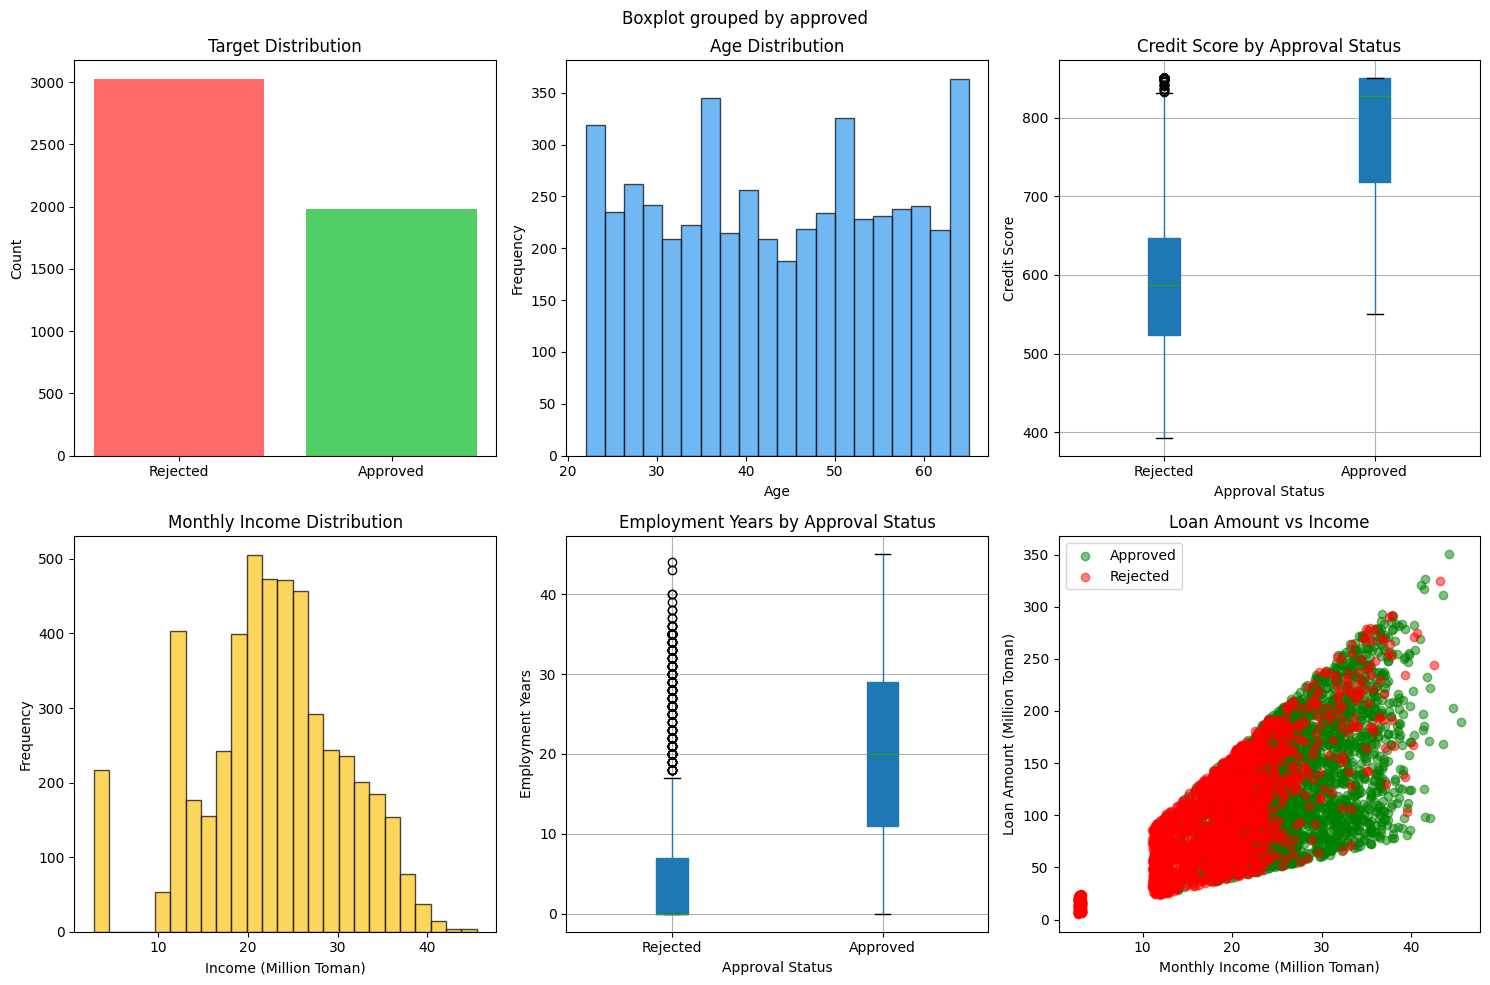

In [25]:
print("\n" + "=" * 70)
print("Step 3: Data Visualizations")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Exploratory Data Analysis - Loan Approval Dataset", fontsize=14, fontweight="bold")

# Plot 1: Target Distribution (Bar Chart)
ax1 = axes[0, 0]
target_counts = df["approved"].value_counts()
colors = ["#ff6b6b", "#51cf66"]
ax1.bar(["Rejected", "Approved"], target_counts.values, color=colors)
ax1.set_title("Target Distribution", fontsize=12)
ax1.set_ylabel("Count")

# Plot 2: Age Distribution
ax2 = axes[0, 1]
ax2.hist(df["age"], bins=20, color="#339af0", edgecolor="black", alpha=0.7)
ax2.set_title("Age Distribution", fontsize=12)
ax2.set_xlabel("Age")
ax2.set_ylabel("Frequency")

# Plot 3: Credit Score by Approval Status
ax3 = axes[0, 2]
df.boxplot(column="credit_score", by="approved", ax=ax3, patch_artist=True)
ax3.set_title("Credit Score by Approval Status", fontsize=12)
ax3.set_xlabel("Approval Status")
ax3.set_ylabel("Credit Score")
ax3.set_xticklabels(["Rejected", "Approved"])

# Plot 4: Monthly Income Distribution
ax4 = axes[1, 0]
ax4.hist(df["monthly_income"] / 1_000_000, bins=25, color="#fcc419", edgecolor="black", alpha=0.7)
ax4.set_title("Monthly Income Distribution", fontsize=12)
ax4.set_xlabel("Income (Million Toman)")
ax4.set_ylabel("Frequency")

# Plot 5: Employment Years by Approval
ax5 = axes[1, 1]
df.boxplot(column="employment_years", by="approved", ax=ax5, patch_artist=True)
ax5.set_title("Employment Years by Approval Status", fontsize=12)
ax5.set_xlabel("Approval Status")
ax5.set_ylabel("Employment Years")
ax5.set_xticklabels(["Rejected", "Approved"])

# Plot 6: Loan Amount vs Income (Scatter)
ax6 = axes[1, 2]
approved = df[df["approved"] == 1]
rejected = df[df["approved"] == 0]
ax6.scatter(approved["monthly_income"] / 1e6, approved["loan_amount"] / 1e6, alpha=0.5, c="green", label="Approved")
ax6.scatter(rejected["monthly_income"] / 1e6, rejected["loan_amount"] / 1e6, alpha=0.5, c="red", label="Rejected")
ax6.set_title("Loan Amount vs Income", fontsize=12)
ax6.set_xlabel("Monthly Income (Million Toman)")
ax6.set_ylabel("Loan Amount (Million Toman)")
ax6.legend()

plt.tight_layout()
plt.savefig(f"{ARTIFACT_FOLDER}/eda_plots.png", dpi=150)
print("✅ EDA plots saved: eda_plots.png")


#### Data Cleaning

In [26]:
print("\n" + "=" * 70)
print("Step 4: Data Cleaning")
print("=" * 70)

# Remove duplicates
before_dup = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before_dup - len(df)}")

# Handle missing values
print(f"\nMissing values before cleaning:")
print(df.isnull().sum())

if df["credit_score"].isnull().sum() > 0:
    median_score = df["credit_score"].median()
    df["credit_score"] = df["credit_score"].fillna(median_score)
    print(f"✅ credit_score filled with median: {median_score:.0f}")

print("\n✅ Data cleaning completed")



Step 4: Data Cleaning
Duplicates removed: 0

Missing values before cleaning:
age                          0
marital_status               0
dependents                   0
employment_type              0
employment_years             0
monthly_income               0
credit_score               116
loan_amount                  0
loan_term_months             0
loan_purpose                 0
has_other_loans              0
late_payments_last_year      0
approved                     0
dtype: int64
✅ credit_score filled with median: 723

✅ Data cleaning completed


#### Data Preprocessing

##### Encoding

In [27]:
print("\n" + "=" * 70)
print("Step 5: Encoding Categorical Variables")
print("=" * 70)

df["marital_num"] = df["marital_status"].map({"مجرد": 0, "متأهل": 1})

le_employment = LabelEncoder()
df["employment_num"] = le_employment.fit_transform(df["employment_type"])

le_purpose = LabelEncoder()
df["purpose_num"] = le_purpose.fit_transform(df["loan_purpose"])

df = df.drop(columns=["marital_status", "employment_type", "loan_purpose"])

print("✅ Encoding completed")
print(f"   marital_status: Single=0, Married=1")
print(f"   employment_type: {dict(zip(le_employment.classes_, range(len(le_employment.classes_))))}")
print(f"   loan_purpose: {dict(zip(le_purpose.classes_, range(len(le_purpose.classes_))))}")



Step 5: Encoding Categorical Variables
✅ Encoding completed
   marital_status: Single=0, Married=1
   employment_type: {'آزاد': 0, 'بازنشسته': 1, 'بیکار': 2, 'دولتی': 3, 'فریلنس': 4, 'کارمند': 5}
   loan_purpose: {'تحصیل': 0, 'خودرو': 1, 'شخصی': 2, 'مسکن': 3, 'پزشکی': 4, 'کسب_و_کار': 5}


### 4- Featuer Engineering

Feature Selection

In [28]:
print("\n" + "=" * 70)
print("Step 6: Feature Selection")
print("=" * 70)

feature_columns = [
    "age",
    "dependents",
    "employment_years",
    "monthly_income",
    "credit_score",
    "loan_amount",
    "loan_term_months",
    "has_other_loans",
    "late_payments_last_year",
    "marital_num",
    "employment_num",
    "purpose_num",
]

X = df[feature_columns]
y = df["approved"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")



Step 6: Feature Selection
X shape: (5000, 12)
y shape: (5000,)


### 5- Model Training

Train-Test Split

In [29]:
print("\n" + "=" * 70)
print("Step 7: Train-Test Split")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data: {X_train.shape}")
print(f"Test data: {X_test.shape}")



Step 7: Train-Test Split
Training data: (4000, 12)
Test data: (1000, 12)


Train Model

In [30]:
print("\n" + "=" * 70)
print("Step 8: Train Decision Tree Model")
print("=" * 70)

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    class_weight="balanced",  # ← این خط را اضافه کنید
    random_state=42,
)

model.fit(X_train, y_train)
print("✅ Decision Tree model trained")



Step 8: Train Decision Tree Model
✅ Decision Tree model trained


### 6- Model Evaluation

##### Confusion Matrix

In [31]:
print("\n" + "=" * 70)
print("Step 9: Model Evaluation")
print("=" * 70)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"🎯 Overall Accuracy: {accuracy * 100:.1f}%")

cm = confusion_matrix(y_test, y_pred)
print("\n📊 Confusion Matrix:")
print(f"                 Prediction")
print(f"              Reject  Approve")
print(f"Actual Reject  {cm[0, 0]:5d}   {cm[0, 1]:5d}")
print(f"Actual Approve {cm[1, 0]:5d}   {cm[1, 1]:5d}")

tn, fp, fn, tp = cm.ravel()
print(f"\n📈 Detailed Performance:")
print(f"   Reject Class Accuracy: {tn / (tn + fp) * 100:.1f}%")
print(f"   Approve Class Accuracy: {tp / (tp + fn) * 100:.1f}%")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Reject", "Approve"]))



Step 9: Model Evaluation
🎯 Overall Accuracy: 82.8%

📊 Confusion Matrix:
                 Prediction
              Reject  Approve
Actual Reject    369      26
Actual Approve   146     459

📈 Detailed Performance:
   Reject Class Accuracy: 93.4%
   Approve Class Accuracy: 75.9%

📋 Classification Report:
              precision    recall  f1-score   support

      Reject       0.72      0.93      0.81       395
     Approve       0.95      0.76      0.84       605

    accuracy                           0.83      1000
   macro avg       0.83      0.85      0.83      1000
weighted avg       0.86      0.83      0.83      1000



##### Visualize Decision Tree


Step 10: Visualize the Decision Tree
✅ Decision tree saved: decision_tree.png
✅ Full decision tree saved: decision_tree_full.txt

📊 Tree Statistics:
   Total nodes: 47
   Max depth: 5
   Total leaves: 24


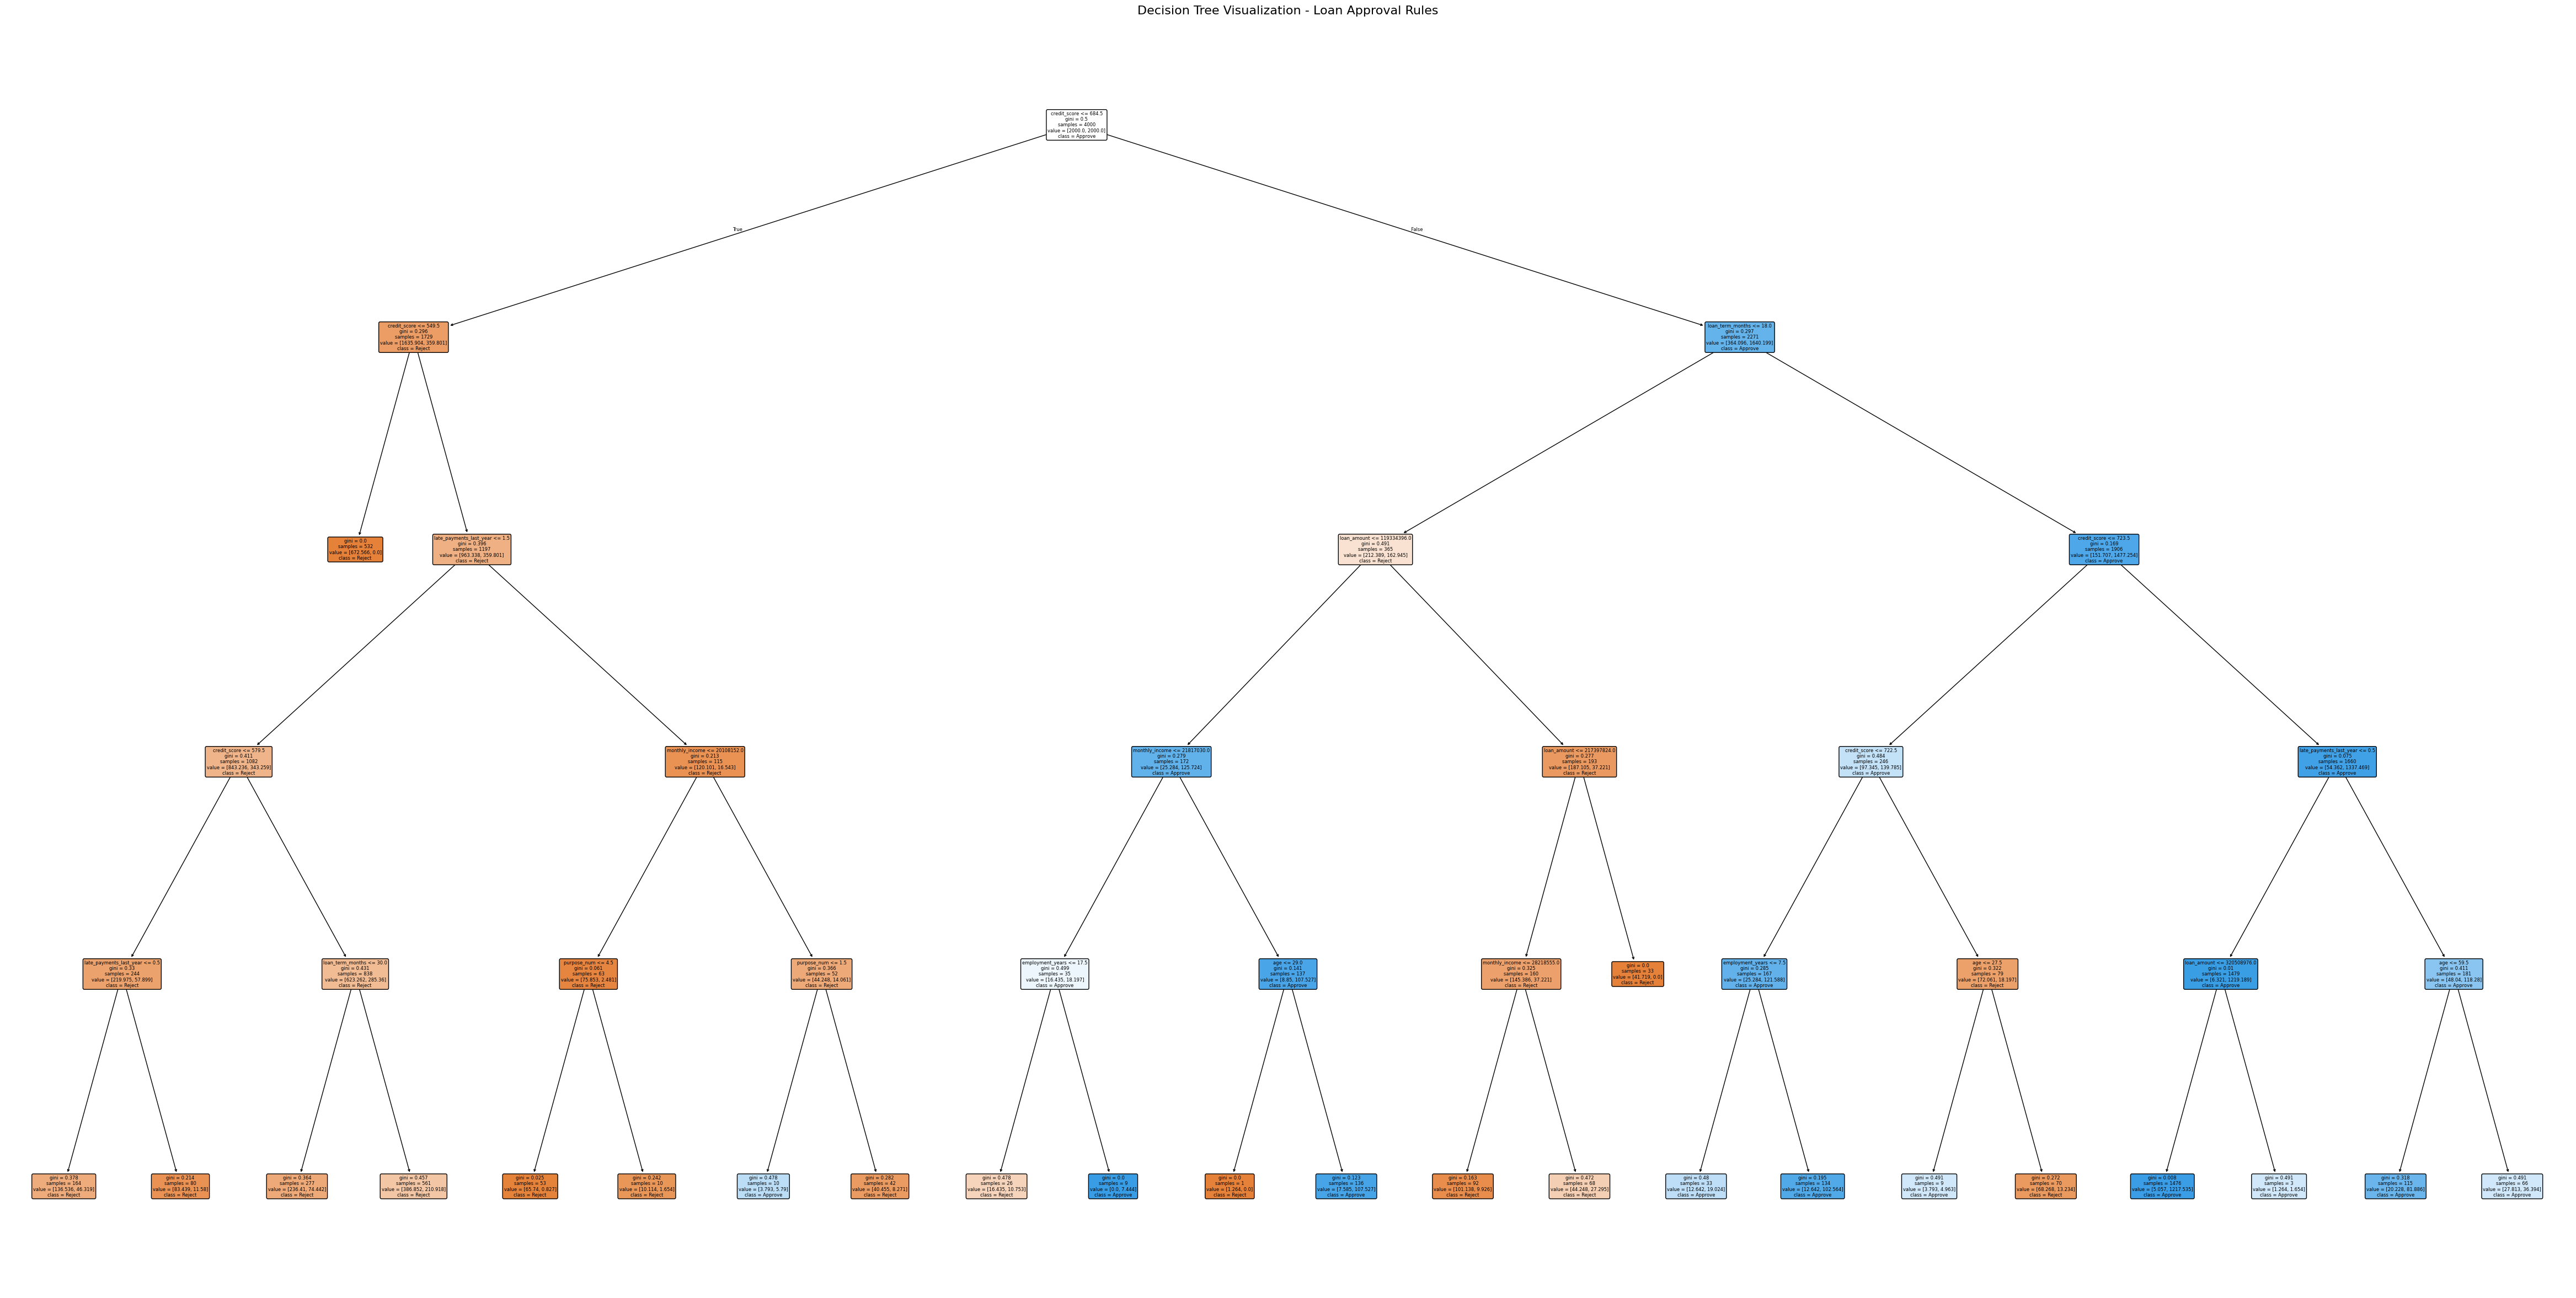

In [32]:
print("\n" + "=" * 70)
print("Step 10: Visualize the Decision Tree")
print("=" * 70)

# تصویر بزرگ
plt.figure(figsize=(60, 30))
plot_tree(
    model, feature_names=feature_columns, class_names=["Reject", "Approve"], filled=True, rounded=True, fontsize=6
)
plt.title("Decision Tree Visualization - Loan Approval Rules", fontsize=16)
plt.savefig(f"{ARTIFACT_FOLDER}/decision_tree.png", dpi=300, bbox_inches="tight")
print("✅ Decision tree saved: decision_tree.png")

# متن کامل

tree_text = export_text(model, feature_names=feature_columns)

with open(f"{ARTIFACT_FOLDER}/decision_tree_full.txt", "w", encoding="utf-8") as f:
    f.write(tree_text)
print("✅ Full decision tree saved: decision_tree_full.txt")

# آمار درخت
n_nodes = model.tree_.node_count
depth = model.tree_.max_depth
n_leaves = model.tree_.n_leaves
print(f"\n📊 Tree Statistics:")
print(f"   Total nodes: {n_nodes}")
print(f"   Max depth: {depth}")
print(f"   Total leaves: {n_leaves}")


##### Feature Importance


Step 11: Feature Importance

🔥 Most Important Features (Top 5):
   credit_score: 0.7676
   loan_term_months: 0.1104
   loan_amount: 0.0656
   late_payments_last_year: 0.0255
   monthly_income: 0.0147
✅ Feature importance plot saved: feature_importance.png


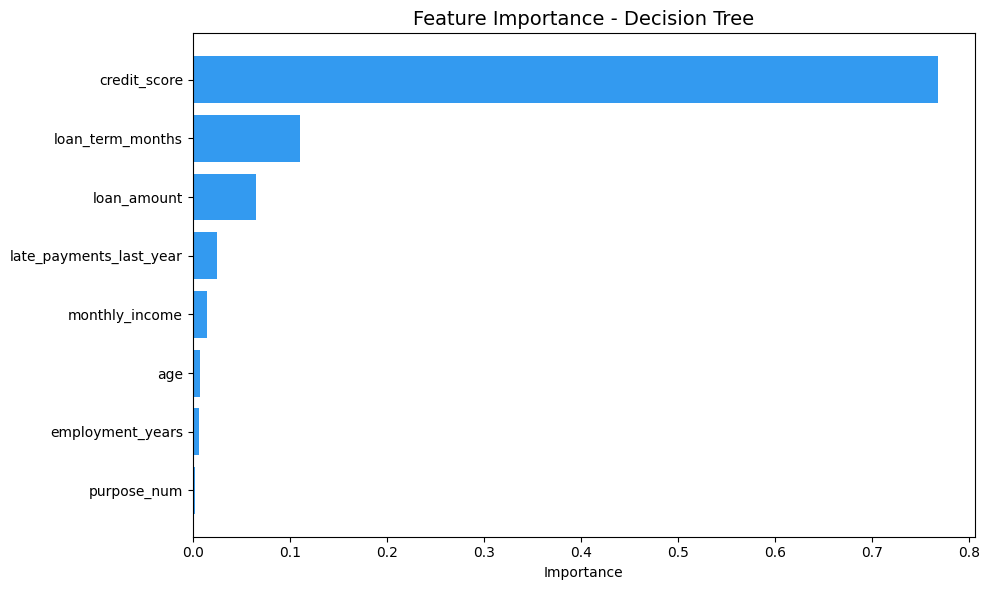

In [33]:
print("\n" + "=" * 70)
print("Step 11: Feature Importance")
print("=" * 70)

feature_importance = pd.DataFrame({"Feature": feature_columns, "Importance": model.feature_importances_}).sort_values(
    "Importance", ascending=False
)

print("\n🔥 Most Important Features (Top 5):")
for i, row in feature_importance.head(5).iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(8)["Feature"], feature_importance.head(8)["Importance"], color="#339af0")
plt.xlabel("Importance")
plt.title("Feature Importance - Decision Tree", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{ARTIFACT_FOLDER}/feature_importance.png", dpi=150)
print("✅ Feature importance plot saved: feature_importance.png")


### 7- Model Deployment

In [34]:
print("\n" + "=" * 70)
print("Step 12: Save Model")
print("=" * 70)

model_package = {
    "model": model,
    "employment_encoder": le_employment,
    "purpose_encoder": le_purpose,
    "features": feature_columns,
    "performance": {"accuracy": accuracy, "confusion_matrix": cm.tolist()},
}

joblib.dump(model_package, f"{ARTIFACT_FOLDER}/loan_model.pkl")
print("✅ Model saved: loan_model.pkl")



Step 12: Save Model
✅ Model saved: loan_model.pkl
